#การรันโค้ดให้รันตามลำดับเลย#

#---------------------------4 ขั้นตอนบนคือ---------------------------


#1.เชื่อมกับ drive #
#2.เช็ค file path#  
#3.เช็คอีกที#  
#4.เช็คว่ามีไฟล์ test , train มั้ย#


(ถ้ามีจะเป็น  angry  happy
angry  happy )

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
trainpath = '/content/drive/MyDrive/dog_emotions/train/'
testpath  = '/content/drive/MyDrive/dog_emotions/test/'


In [ ]:
!ls /content/drive/MyDrive/

 04.pdf
 45B998A7-B1C3-4A27-A4ED-BA4B81E299DD.jpeg
'673380044-4 นฤเศรษฐ์ อภิลักขิตพงศ์ .MP4'
 AI.pdf
 Akania.gdoc
 Classroom
'Colab Notebooks'
 CS.gdoc
 Designer.png
 dog_emotions
 IMG_4276.jpeg
 IMG_5695.jpeg
 IMG_7219.jpeg
 IMG_7392.jpeg
'Lab02 - Answer paper template.gdoc'
'Lab03 - Answer paper template.gdoc'
'Lab04 - Answer paper template (1).gdoc'
'Lab04 - Answer paper template (2).gdoc'
'Lab04 - Answer paper template.gdoc'
'Lab05 - Aggregation and Composition Relationship.gdoc'
'Lab05 - Answer paper template (1).gdoc'
'Lab05 - Answer paper template (2).gdoc'
'Lab05 - Answer paper template.gdoc'
'Lab06 - Answer paper template.gdoc'
'Lab07 - Answer paper template (1).gdoc'
'Lab07 - Answer paper template (2).gdoc'
'Lab07 - Answer paper template (3).gdoc'
'Lab07 - Answer paper template.gdoc'
'Lab08 - Abstract class & interface (1).gdoc'
'Lab08 - Abstract class & interface (2).gdoc'
'Lab08 - Abstract class & interface (3).gdoc'
'Lab08 - Abstract class & interface.gdoc'
'Lab09 - Lambda

In [ ]:
!ls /content/drive/MyDrive/dog_emotions/train/
!ls /content/drive/MyDrive/dog_emotions/test/

angry  happy
angry  happy


.

.

.

#ขั้นตอนนี้เป็นการสร้างโมเดล Convolutional Neural Network (CNN) สำหรับการจำแนกประเภท (classification) โดยใช้ไลบรารี Keras ใน TensorFlow#

In [ ]:

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential

model = Sequential() # Changed 'odel' to 'model'

# เปลี่ยนจากการใช้ input_shape ไปใช้ Input Layer
model.add(Input(shape=(128, 128, 3)))  # ใช้ Input แทนการใช้ input_shape

model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

.

.

.

In [ ]:
from os import listdir
from os.path import join
import cv2
import numpy as np
from tqdm import tqdm

# กำหนด path สำหรับ train และ test
trainpath = '/content/drive/MyDrive/dog_emotions/train/'  # ให้แน่ใจว่า path นี้ถูกต้อง
testpath = '/content/drive/MyDrive/dog_emotions/test/'  # ให้แน่ใจว่า path นี้ถูกต้อง

# สร้าง list ของโฟลเดอร์ที่เก็บข้อมูลใน train และ test
trainImg = [join(trainpath, f) for f in listdir(trainpath) if listdir(join(trainpath, f))]
testImg = [join(testpath, f) for f in listdir(testpath) if listdir(join(testpath, f))]

# แสดงผลลัพธ์เพื่อให้มั่นใจว่าได้ดึงข้อมูลที่ถูกต้อง
print("Train Image Paths: ", trainImg)
print("Test Image Paths: ", testImg)

# ฟังก์ชันเพื่อแปลงภาพและกำหนด Label
def img2data(path):
    rawImgs = []
    labels = []
    for imagePath in path:
        # ตรวจสอบว่าในแต่ละโฟลเดอร์มีไฟล์ภาพหรือไม่
        for item in tqdm(listdir(imagePath)):
            file = join(imagePath, item)
            if file.endswith('jpg') or file.endswith('png'):  # ตรวจสอบไฟล์ที่เป็นภาพ
                img = cv2.imread(file)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # เปลี่ยนเป็น RGB
                img = cv2.resize(img, (128, 128))  # ปรับขนาดภาพ
                rawImgs.append(img)

                # สร้าง Label ตามโฟลเดอร์ที่อยู่ใน path
                label = imagePath.split('/')[-1]  # ดึงชื่อโฟลเดอร์เป็น label
                if label == 'happy':
                    labels.append([1, 0])  # Happy -> [1, 0]
                elif label == 'angry':
                    labels.append([0, 1])  # Angry -> [0, 1]

    return rawImgs, labels

# โหลดข้อมูลสำหรับ train และ test
x_train, y_train = img2data(trainImg)
x_test, y_test = img2data(testImg)

# แปลงข้อมูลเป็น numpy arrays และ normalize
x_train = np.array(x_train).astype('float32') / 255.0
y_train = np.array(y_train)
x_test = np.array(x_test).astype('float32') / 255.0
y_test = np.array(y_test)

# สร้างโมเดล CNN
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.layers import Input

model = Sequential()
model.add(Input(shape=(128, 128, 3)))  # ใช้ Input แทนการใช้ input_shape
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax'))

# คอมไพล์และฝึกโมเดล
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))


Train Image Paths:  ['/content/drive/MyDrive/dog_emotions/train/angry', '/content/drive/MyDrive/dog_emotions/train/happy']
Test Image Paths:  ['/content/drive/MyDrive/dog_emotions/test/angry', '/content/drive/MyDrive/dog_emotions/test/happy']


100%|██████████| 1076/1076 [00:30<00:00, 35.18it/s] 


Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6103 - loss: 0.6892 - val_accuracy: 0.6630 - val_loss: 0.6273
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6691 - loss: 0.6293 - val_accuracy: 0.7283 - val_loss: 0.5759
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7095 - loss: 0.5878 - val_accuracy: 0.7511 - val_loss: 0.5168
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7334 - loss: 0.5497 - val_accuracy: 0.7603 - val_loss: 0.4904
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.7493 - loss: 0.5041 - val_accuracy: 0.7954 - val_loss: 0.4516


.

.

.

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

# สร้างโมเดล
model = Sequential()

# เพิ่ม Conv2D Layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPooling2D((2, 2)))

# เพิ่ม Conv2D Layer อื่นๆ
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# เพิ่ม Dropout เพื่อป้องกัน Overfitting
model.add(Dropout(0.5))

# Flatten layer เพื่อแปลงข้อมูลเป็น 1D
model.add(Flatten())

# Dense layer สำหรับการทำนายผล
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # ใช้ dropout ใน Dense layer
model.add(Dense(2, activation='softmax'))  # สองผลลัพธ์: Happy หรือ Angry

# คอมไพล์โมเดล
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# ฝึกโมเดล (ใช้ข้อมูลที่เตรียมไว้ก่อนหน้า)
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.6182 - loss: 1.2247 - val_accuracy: 0.6907 - val_loss: 0.6018
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7238 - loss: 0.5760 - val_accuracy: 0.7498 - val_loss: 0.5258
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 72s 996ms/step - accuracy: 0.7357 - loss: 0.5641 - val_accuracy: 0.7560 - val_loss: 0.5019
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 82s 995ms/step - accuracy: 0.7608 - loss: 0.4994 - val_accuracy: 0.7831 - val_loss: 0.4302
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7969 - loss: 0.4536 - val_accuracy: 0.8521 - val_loss: 0.3746


.

.

.

.

#โค้ดนี้เป็นการใช้ Data Augmentation เพื่อขยายชุดข้อมูลการฝึก (training data) โดยการปรับแต่งภาพให้มีความหลากหลายมากขึ้นในระหว่างการฝึกโมเดล Convolutional Neural Network (CNN)#   **############อันนี้โคตรนานแต่เพื่อความแม่น#**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# สร้าง ImageDataGenerator เพื่อทำ Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,    # หมุนภาพได้ 20 องศา
    width_shift_range=0.2,  # เลื่อนภาพแนวนอนได้ 20%
    height_shift_range=0.2, # เลื่อนภาพแนวตั้งได้ 20%
    shear_range=0.2,      # การบิดเบือนภาพ
    zoom_range=0.2,       # การซูมภาพ
    horizontal_flip=True, # พลิกภาพแนวนอนได้
    fill_mode='nearest'   # เติมช่องว่างที่เกิดขึ้นเมื่อหมุนหรือเลื่อนภาพ
)

# ตัวอย่างการใช้งานเพื่อเพิ่มข้อมูลในระหว่างการฝึก
datagen.fit(x_train)
                                                                        #ตรงนี้สามารถลดได้
# ฝึกโมเดลโดยใช้ Data Augmentation                                 v
model.fit(datagen.flow(x_train, y_train, batch_size=32), epochs=20, validation_data=(x_test, y_test))

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7244 - loss: 0.5950 - val_accuracy: 0.7708 - val_loss: 0.4893
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7439 - loss: 0.5628 - val_accuracy: 0.7677 - val_loss: 0.4906
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7241 - loss: 0.5639 - val_accuracy: 0.7634 - val_loss: 0.4927
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7287 - loss: 0.5911 - val_accuracy: 0.7646 - val_loss: 0.5179
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.7533 - loss: 0.5365 - val_accuracy: 0.7800 - val_loss: 0.5022
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7513 - loss: 0.5380 - val_accuracy: 0.7683 - val_loss: 0.4837
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.7344 - loss: 0.5397 - val_accuracy: 0.7579 - val_loss: 0.5118
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.7607 - loss: 0.5264 - val_accuracy: 0.7646 - val_loss:

.

.

.

.

##############################################################################################################################################################################################

#Accuracy กับ Loss#

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 673ms/step - accuracy: 0.7685 - loss: 0.5122 - val_accuracy: 0.7905 - val_loss: 0.4405
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 603ms/step - accuracy: 0.7949 - loss: 0.4486 - val_accuracy: 0.8096 - val_loss: 0.4366
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 659ms/step - accuracy: 0.8082 - loss: 0.4300 - val_accuracy: 0.8546 - val_loss: 0.3404
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 38s 593ms/step - accuracy: 0.8331 - loss: 0.3620 - val_accuracy: 0.8700 - val_loss: 0.2734
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 44s 652ms/step - accuracy: 0.8563 - loss: 0.3067 - val_accuracy: 0.9174 - val_loss: 0.2268
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 33s 659ms/step - accuracy: 0.8811 - loss: 0.2842 - val_accuracy: 0.9328 - val_loss: 0.1448
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 37s 585ms/step - accuracy: 0.9207 - loss: 0.2016 - val_accuracy: 0.9661 - val_loss: 0.1142
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 31s 603ms/step - accuracy: 0.9422 - loss: 0.1641 - val_accu

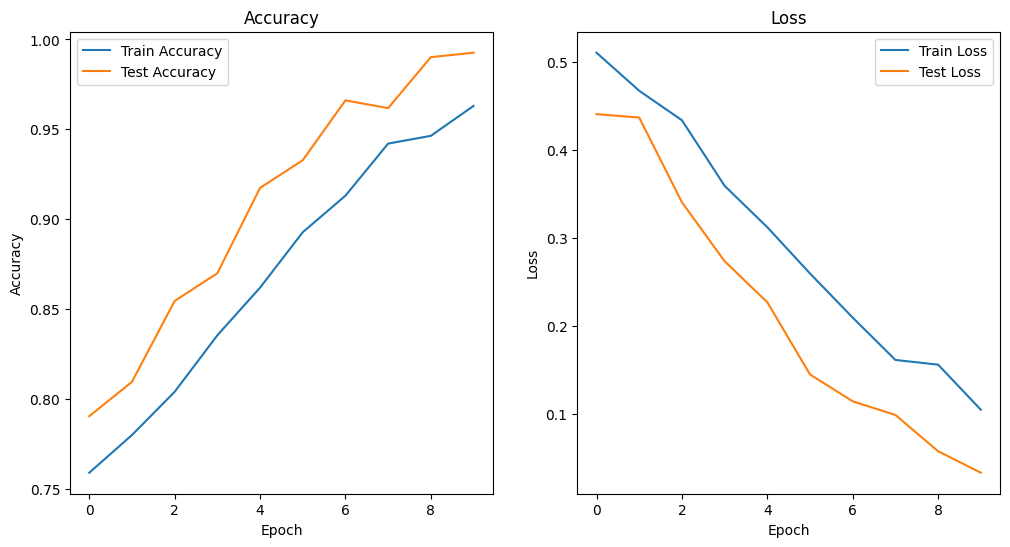

In [ ]:
import matplotlib.pyplot as plt

# ฝึกโมเดลและเก็บค่า loss และ accuracy ในแต่ละ epoch
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

# แสดงกราฟความแม่นยำ (accuracy) และการสูญเสีย (loss)
# กราฟความแม่นยำในข้อมูล train และ test
plt.figure(figsize=(12, 6))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


.

.

.

.

.

##############################################################################################################################################################################################
# YOU CAN UPLOAD PICTURE OF DOG HERE (happy , angry)


โค้ดอัพเกรด

Version upgrade
-เพิ่มกราฟสำหรับดูพฤติกรรมสุนัขในระยะยาว
-เพิ่มคำแนะนำหลังจากที่ได้วิเคราะห์อารมณ์สุนัข
-เพิ่มคำแนะนำด้วยเสียง
-ทำนายอารมณ์ล่วงหน้า
-สร้างไฟล์เก็บสถิติการทำนาย

Saving 482506985_1004996531514646_8205053367226403256_n.jpg to 482506985_1004996531514646_8205053367226403256_n.jpg
Saving 482619590_1040907604532221_2181428975430172997_n.jpg to 482619590_1040907604532221_2181428975430172997_n.jpg
Saving 482700651_951971226705682_6928117115972706423_n.jpg to 482700651_951971226705682_6928117115972706423_n.jpg
Saving 482712960_631636349489838_7969047993151514146_n.jpg to 482712960_631636349489838_7969047993151514146_n.jpg
Saving 483479413_1177624827421035_5782751155762742281_n.jpg to 483479413_1177624827421035_5782751155762742281_n.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step


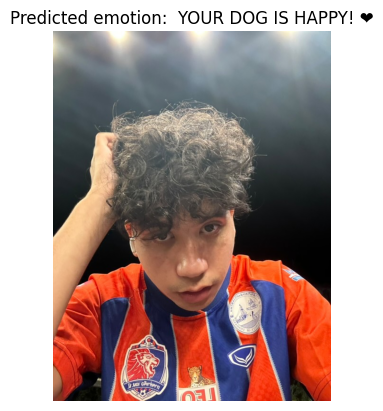

<Figure size 50000x5000 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step


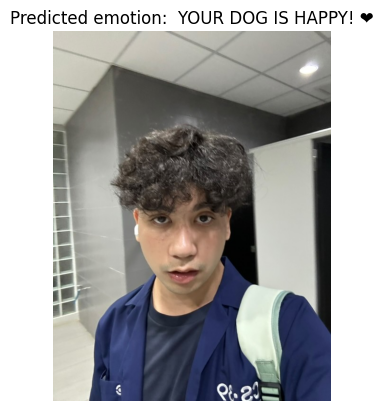

<Figure size 50000x5000 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step


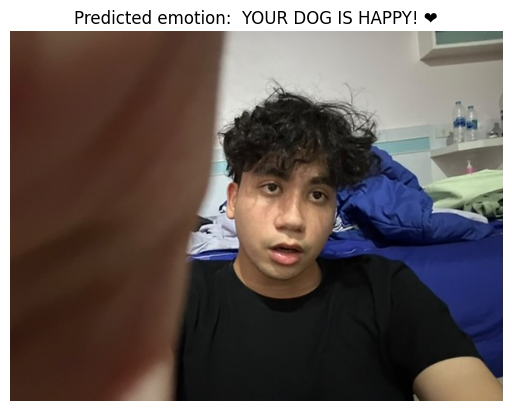

<Figure size 50000x5000 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


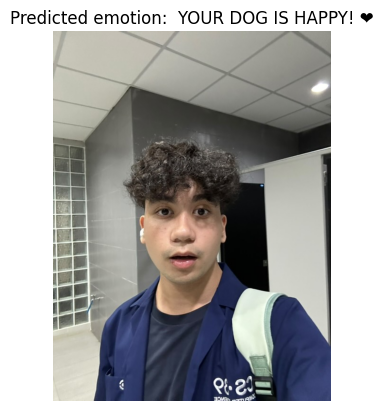

<Figure size 50000x5000 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step


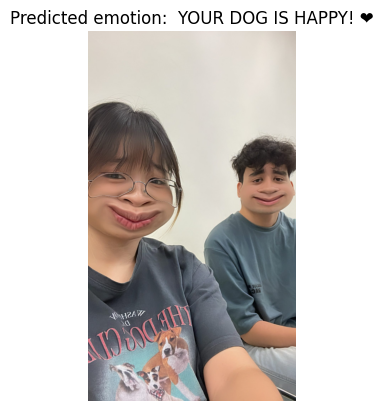

<Figure size 50000x5000 with 0 Axes>

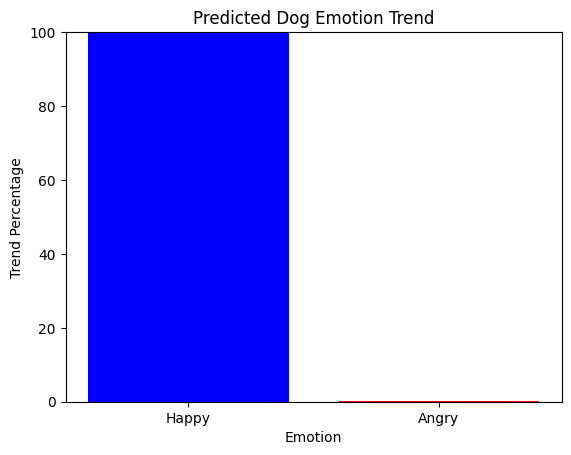

 
     แนวโน้ม: สุนัขของคุณมีโอกาสมีความสุขมากขึ้นในอนาคต! 🎉
 
คำแนะนำ: เล่นกับพวกเขาบ่อย ๆ ให้รางวัล และดูแลสภาพแวดล้อมให้สงบ
  1. พาไปเดินเล่นหรือเล่นของเล่นที่พวกเขาชอบ เพื่อกระตุ้นความสุข
  2. ให้รางวัลเมื่อพวกเขาทำพฤติกรรมดี ๆ เช่น นั่งหรือทำตามคำสั่ง
  3. สร้างบรรยากาศที่สงบ โดยหลีกเลี่ยงเสียงดังหรือสิ่งที่อาจทำให้พวกเขารู้สึกเครียด
 


In [ ]:
from keras.applications import VGG16
from keras.layers import Dense, GlobalAveragePooling2D
from keras.models import Model
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from keras.applications.vgg16 import preprocess_input
from collections import Counter
import pickle
from IPython.display import display, Audio

# โหลดโมเดล VGG16 ที่ฝึกแล้วจาก ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# เพิ่มชั้นสำหรับทำนาย
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(2, activation='softmax')(x)  # 2 class: Angry, Happy

# สร้างโมเดล
model = Model(inputs=base_model.input, outputs=predictions)

# ปิดการฝึกในส่วนของ base model
for layer in base_model.layers:
    layer.trainable = False

# เปิดการฝึกในบางเลเยอร์ของ base model
for layer in base_model.layers[-4:]:  # เปิดการฝึก 4 เลเยอร์สุดท้าย
    layer.trainable = True

# คอมไพล์โมเดล
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ใช้ ImageDataGenerator สำหรับการเพิ่มข้อมูล (Data Augmentation)
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# โหลดสถิติที่บันทึกไว้ก่อนหน้า
try:
    with open("emotion_stats.pkl", "rb") as f:
        emotion_stats = pickle.load(f)
except FileNotFoundError:
    emotion_stats = Counter()

try:
    with open("probability_scores.pkl", "rb") as f:
        probability_scores = pickle.load(f)
except FileNotFoundError:
    probability_scores = []

# ฟังก์ชันทำนาย
def predict_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))  # ขนาดที่เหมาะสมกับ VGG16
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)  # เตรียมข้อมูลตามมาตรฐานของ VGG16

    prediction = model.predict(img_array)[0]  # ดึงค่าความน่าจะเป็น
    probability_scores.append(prediction)

    if prediction[1] > prediction[0]:
        emotion_stats['Happy'] += 1
        return " YOUR DOG IS HAPPY! ❤️"
    else:
        emotion_stats['Angry'] += 1
        return " YOUR DOG IS ANGRY! 😠"

# อัปโหลดไฟล์จากเครื่อง
uploaded = files.upload()

# ทำนายอารมณ์จากไฟล์ที่อัปโหลด
for file_name in uploaded.keys():
    image_path = '/content/' + file_name
    result = predict_image(image_path)

    # แสดงภาพพร้อมกับข้อความ
    img = image.load_img(image_path)  # โหลดภาพในขนาดเดิมที่อัปโหลด

    plt.imshow(img)
    plt.title(f"Predicted emotion: {result}")
    plt.axis('off')  # ปิดแกน x และ y
    plt.figure(figsize=(500, 50))
    plt.show()

# คำนวณแนวโน้มอารมณ์ล่วงหน้า
if probability_scores:
    avg_emotion = np.mean(probability_scores, axis=0)
    happy_trend = avg_emotion[1] * 100
    angry_trend = avg_emotion[0] * 100
else:
    happy_trend, angry_trend = 50, 50  # ค่าเริ่มต้นกรณีไม่มีข้อมูล

# บันทึกสถิติสำหรับการใช้งานครั้งถัดไป
with open("emotion_stats.pkl", "wb") as f:
    pickle.dump(emotion_stats, f)

with open("probability_scores.pkl", "wb") as f:
    pickle.dump(probability_scores, f)

# แสดงผลการวิเคราะห์แนวโน้มอารมณ์
labels = ['Happy', 'Angry']
values = [happy_trend, angry_trend]
plt.bar(labels, values, color=['blue', 'red'])
plt.xlabel('Emotion')
plt.ylabel('Trend Percentage')
plt.title('Predicted Dog Emotion Trend')
plt.ylim(0, 100)
plt.show()
print(" ")




# สรุปผลและให้คำแนะนำ
if happy_trend > angry_trend:
    print("     แนวโน้ม: สุนัขของคุณมีโอกาสมีความสุขมากขึ้นในอนาคต! 🎉")
    print(" ")
    print("คำแนะนำ: เล่นกับพวกเขาบ่อย ๆ ให้รางวัล และดูแลสภาพแวดล้อมให้สงบ")
    print("  1. พาไปเดินเล่นหรือเล่นของเล่นที่พวกเขาชอบ เพื่อกระตุ้นความสุข")
    print("  2. ให้รางวัลเมื่อพวกเขาทำพฤติกรรมดี ๆ เช่น นั่งหรือทำตามคำสั่ง")
    print("  3. สร้างบรรยากาศที่สงบ โดยหลีกเลี่ยงเสียงดังหรือสิ่งที่อาจทำให้พวกเขารู้สึกเครียด")
    print(" ")
    display(Audio("/content/drive/MyDrive/dog_emotions/sound/happy_bark.mp3", autoplay=True))
elif angry_trend > happy_trend:
    print("     แนวโน้ม: สุนัขของคุณมีแนวโน้มที่จะโกรธบ่อยขึ้น! 😠")
    print(" ")
    print("คำแนะนำ: หลีกเลี่ยงสิ่งกระตุ้นที่ทำให้พวกเขาเครียด และให้ความรักมากขึ้น")
    print("  1. ฝึกให้พวกเขาควบคุมอารมณ์ด้วยคำสั่งง่าย ๆ เช่น 'นั่ง' ")
    print("  2. สังเกตสิ่งกระตุ้น เช่น เสียงดังหรือการพบเจอกับสัตว์อื่น ๆ และหลีกเลี่ยง")
    print("  3. ให้เวลาเล่นและออกกำลังกายเพื่อช่วยให้พวกเขาผ่อนคลาย")
    print(" ")
    display(Audio("/content/drive/MyDrive/dog_emotions/sound/angry_bark.mp3", autoplay=True))
else:
    print("     แนวโน้ม: อารมณ์ของสุนัขมีความสมดุล 🐶")
    print(" ")
    print("คำแนะนำ: สังเกตพฤติกรรมของพวกเขาและปรับวิธีดูแลตามสถานการณ์")
    print("  1. สังเกตอารมณ์ของพวกเขาอย่างใกล้ชิด และปรับการดูแลเมื่อจำเป็น")
    print("  2. รักษากิจวัตรประจำวันให้สม่ำเสมอ เพื่อให้พวกเขารู้สึกปลอดภัย")
    print("  3. ให้ความรักและการเอาใจใส่เพื่อรักษาความสัมพันธ์ที่ดี")
    print(" ")
    display(Audio("/content/drive/MyDrive/dog_emotions/sound/normal_bark.mp3", autoplay=True))

